In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import json

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    precision_recall_curve
    )

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
train_df = pd.read_csv(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/train.csv")
test_df  = pd.read_csv(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/test.csv")

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)


Train shape: (239756, 22)
Test shape:  (59939, 22)


In [ ]:
# Checking class balance
target_col = "is_fraud"
print("Class balance (train):")
print(train_df[target_col].value_counts())
print(train_df[target_col].value_counts(normalize=True))

print("\nClass balance (test):")
print(test_df[target_col].value_counts())
print(test_df[target_col].value_counts(normalize=True))

Class balance (train):
is_fraud
0    234466
1      5290
Name: count, dtype: int64
is_fraud
0    0.977936
1    0.022064
Name: proportion, dtype: float64

Class balance (test):
is_fraud
0    58617
1     1322
Name: count, dtype: int64
is_fraud
0    0.977944
1    0.022056
Name: proportion, dtype: float64


In [ ]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col].astype(int)

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col].astype(int)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape,  "y_test shape: ", y_test.shape)

X_train shape: (239756, 21) y_train shape: (239756,)
X_test shape:  (59939, 21) y_test shape:  (59939,)


In [ ]:
categorical_features = ["country", "bin_country", "merchant_category"]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['account_age_days', 'total_transactions_user', 'amount', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'evening', 'weekend', 'channel', 'time_day_sin', 'time_day_cos', 'time_month_sin', 'time_month_cos', 'time_wd_sin', 'time_wd_cos', 'time_hour_sin', 'time_hour_cos']
Categorical features: ['country', 'bin_country', 'merchant_category']


In [ ]:
# Preprocessing Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            drop = "first",
            handle_unknown = "ignore",
            sparse_output = False
        ), categorical_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape: ", X_test_processed.shape)

num_feature_names = numeric_features
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([num_feature_names, cat_feature_names])
print("Total model features:", len(feature_names))


Processed X_train shape: (239756, 40)
Processed X_test shape:  (59939, 40)
Total model features: 40


In [ ]:
lda_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearDiscriminantAnalysis())
    ]
)
lda_pipeline.fit(X_train, y_train)
print("LDA model training complete")


LDA model training complete


In [ ]:
# Class predictions
y_pred_lda = lda_pipeline.predict(X_test)

# Fraud probabilities (class = 1)
y_prob_lda = lda_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
lda_report = classification_report(y_test, y_pred_lda, output_dict=True)
lda_roc_auc = roc_auc_score(y_test, y_prob_lda)
lda_avg_precision = average_precision_score(y_test, y_prob_lda)
lda_cm = confusion_matrix(y_test, y_pred_lda)
lda_fpr, lda_tpr, lda_roc_thresholds = roc_curve(y_test, y_prob_lda)
lda_precision, lda_recall, lda_pr_thresholds = precision_recall_curve(y_test, y_prob_lda)


print("LDA ROC-AUC:", lda_roc_auc)
print("LDA Average Precision (PR-AUC):", lda_avg_precision)

LDA ROC-AUC: 0.927182783533622
LDA Average Precision (PR-AUC): 0.46184667564802995


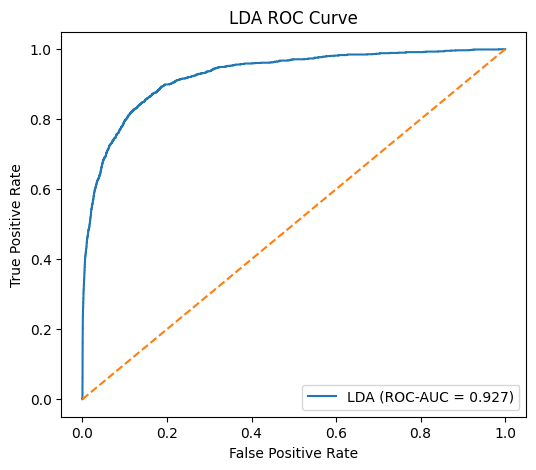

In [ ]:
# ROC CURVE
plt.figure(figsize=(6, 5))
plt.plot(lda_fpr, lda_tpr, label=f"LDA (ROC-AUC = {lda_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LDA ROC Curve")
plt.legend()
plt.show()


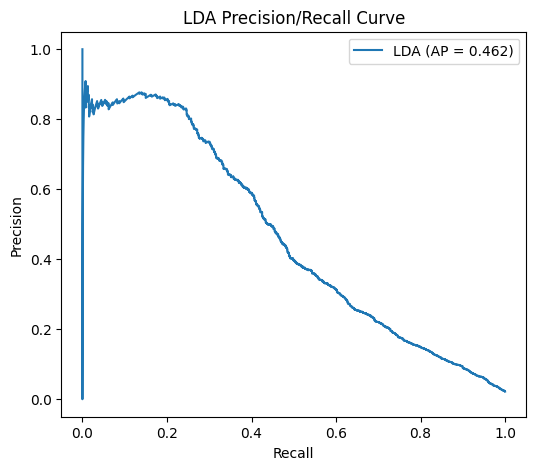

In [ ]:
# Precision/Recall Curve
plt.figure(figsize=(6, 5))
plt.plot(lda_recall, lda_precision, label=f"LDA (AP = {lda_avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LDA Precision/Recall Curve")
plt.legend()
plt.show()


In [ ]:
json_path = "results/lda_results.json"
lda_results = {
    "model": "Linear Discriminant Analysis",
    "classification_report": lda_report,
    "roc_auc": lda_roc_auc,
    "average_precision": lda_avg_precision,
    "confusion_matrix": {
        "labels": ["non_fraud", "fraud"],
        "matrix": lda_cm.tolist()
    },
    "roc_curve": {
        "fpr": lda_fpr.tolist(),
        "tpr": lda_tpr.tolist(),
        "thresholds": lda_roc_thresholds.tolist()
    },
    "precision_recall_curve": {
        "precision": lda_precision.tolist(),
        "recall": lda_recall.tolist(),
        "thresholds": lda_pr_thresholds.tolist()
    }
}

with open(json_path, "w") as f:
    json.dump(lda_results, f, indent=4)

print(f"LDA results successfully saved to {json_path}")

LDA results successfully saved to lda_results.json


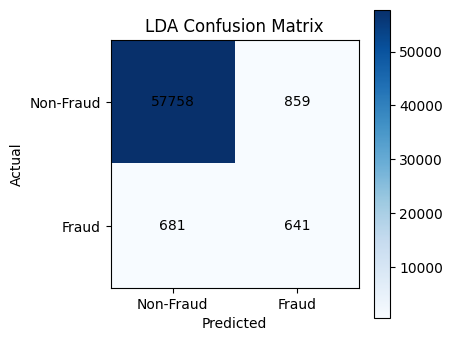

In [ ]:
# Confusion Matrix
plt.figure(figsize=(4, 4))
plt.imshow(lda_cm, cmap = "Blues")
plt.title("LDA Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.yticks([0, 1], ["Non-Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, lda_cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
# Positive and Negative Contributors to Fraud
lda_model = lda_pipeline.named_steps["model"]
lda_coefficients = lda_model.coef_.flatten()
lda_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lda_coefficients
}).sort_values(by="coefficient", ascending=False)

# Top positive contributors to fraud
print("Top features increasing fraud likelihood:")
print(lda_coef_df.head(10))

# Top negative contributors
print("\nTop features decreasing fraud likelihood:")
print(lda_coef_df.tail(10))


Top features increasing fraud likelihood:
                 feature  coefficient
6   shipping_distance_km     1.974439
2                 amount     1.438646
25            country_TR     1.117818
24            country_RO     0.846812
23            country_PL     0.687277
18            country_ES     0.680228
9                channel     0.646029
26            country_US     0.637549
19            country_FR     0.551216
21            country_IT     0.342017

Top features decreasing fraud likelihood:
             feature  coefficient
28    bin_country_FR    -0.228477
35    bin_country_US    -0.239284
32    bin_country_PL    -0.276119
27    bin_country_ES    -0.395217
33    bin_country_RO    -0.458753
5      three_ds_flag    -0.545956
34    bin_country_TR    -0.548009
4         cvv_result    -0.767854
0   account_age_days    -0.816950
3          avs_match    -1.083693
